- Setup Spark Session

In [ ]:

from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Lab01_Enhanced") \
    .getOrCreate()


1. Create DataFrame from Dictionary

In [ ]:
data = [
    {"id": 1, "name": "Ali", "age": 25, "salary": 4000},
    {"id": 2, "name": "Sara", "age": 30, "salary": 7000},
    {"id": 3, "name": "Omar", "age": 22, "salary": None},
    {"id": 4, "name": "Mona", "age": None, "salary": 5000}
]

df = spark.createDataFrame(data)

![Screenshot 2026-05-20 203943.png](<attachment:Screenshot 2026-05-20 203943.png>)
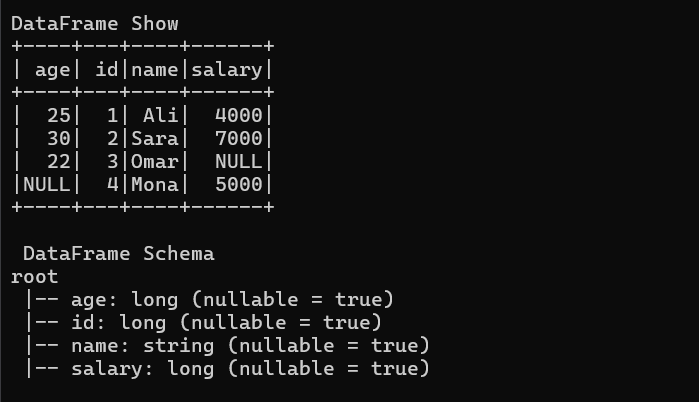

2. Filtering Data

    show salaries greater than 4000 and age > 23

In [ ]:
#Because we have null value in Mona's age it won't show it
filtered_df = df.filter((df["salary"] > 4000) & (df["age"] > 23))
print(" Filtered DataFrame Results ")
filtered_df.show()

![Screenshot 2026-05-20 204641.png](<attachment:Screenshot 2026-05-20 204641.png>)
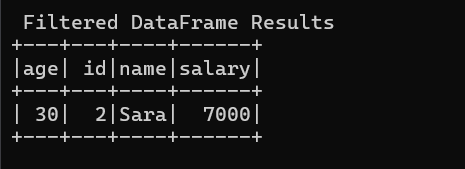

3. Renaming Columns

    rename name column to be full_name

In [ ]:
renamed_df = df.withColumnRenamed("name", "full_name")
print("DataFrame with Renamed Column")
renamed_df.show()

![Screenshot 2026-05-20 204652.png](<attachment:Screenshot 2026-05-20 204652.png>)
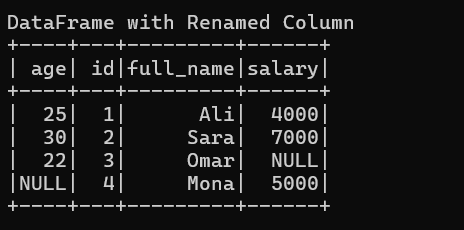

4. Reading CSV with proper schema

In [ ]:
custom_schema = StructType([
    StructField("date", StringType(), True),
    StructField("delay", IntegerType(), True),
    StructField("distance", IntegerType(), True),
    StructField("origin", StringType(), True),
    StructField("destination", StringType(), True)
])

csv_df = spark.read.csv(
    "departuredelays.csv", 
    header=True, 
    schema=custom_schema
)
print("Displaying 10 Rows")
csv_df.show(10)
print("Proper Schema")

![Screenshot 2026-05-20 205529.png](<attachment:Screenshot 2026-05-20 205529.png>)
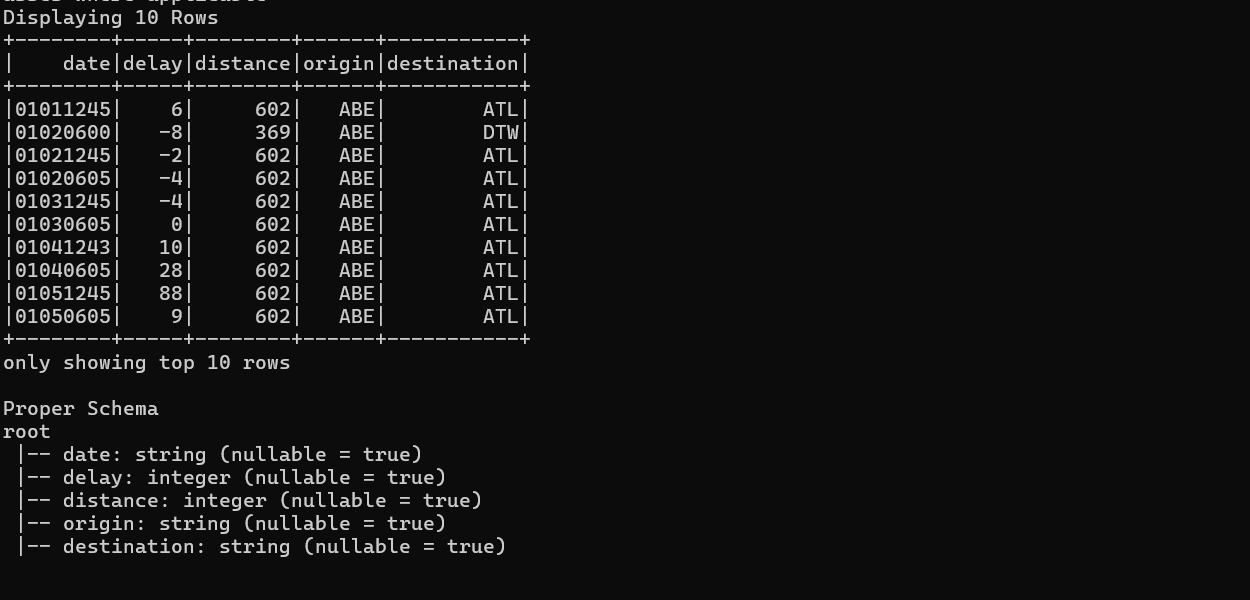


5. 🧪 Data Quality Check

Find:
- Rows with null salary
- Rows with null age


In [ ]:
print("Rows with null salary")
null_salary_df = df.filter(df["salary"].isNull())
null_salary_df.show()

print("Rows with null age")
null_age_df = df.filter(df["age"].isNull())
null_age_df.show()


![Screenshot 2026-05-20 210340.png](<attachment:Screenshot 2026-05-20 210340.png>)
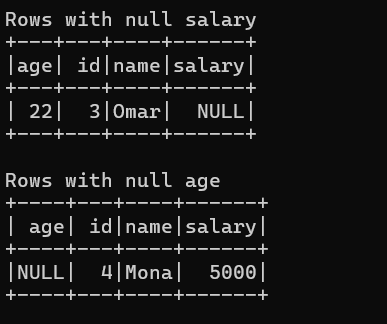

6. Handle null values:
- Replace null salary with 0
- Drop rows where age is null

In [ ]:
print("Replace null salary with 0")
filled_salary_df = df.fillna(value=0, subset=["salary"])
filled_salary_df.show()

print("Drop rows where age is null")
clean_age_df = df.dropna(subset=["age"])
clean_age_df.show()

![Screenshot 2026-05-20 210352.png](<attachment:Screenshot 2026-05-20 210352.png>)
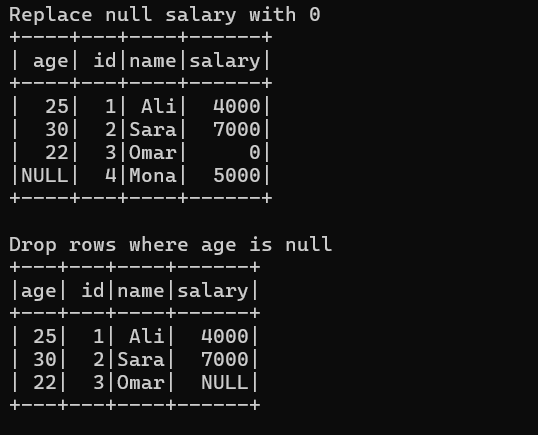